In [ ]:
!pip install -q gdown

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset, DatasetDict
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, pipeline)
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay, recall_score, precision_score, confusion_matrix
from sklearn.exceptions import UndefinedMetricWarning
import torch
from datasets import load_dataset, DatasetDict
import os
import warnings
import seaborn as sns
import pickle
import gdown

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

os.environ["WANDB_DISABLED"] = "true"
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"

In [14]:
df = pd.read_json('https://drive.google.com/uc?export=download&id=1NjvoUnUNAmVPSse1mhRSKQNbarsMThFA', lines=True)
df.head()

,id,verifiable,label,claim,evidence
0,75397,VERIFIABLE,SUPPORTS,Nikolaj Coster-Waldau worked with the Fox Broa...,"[[[92206, 104971, Nikolaj_Coster-Waldau, 7], [..."
1,150448,VERIFIABLE,SUPPORTS,Roman Atwood is a content creator.,"[[[174271, 187498, Roman_Atwood, 1]], [[174271..."
2,214861,VERIFIABLE,SUPPORTS,"History of art includes architecture, dance, s...","[[[255136, 254645, History_of_art, 2]]]"
3,156709,VERIFIABLE,REFUTES,Adrienne Bailon is an accountant.,"[[[180804, 193183, Adrienne_Bailon, 0]]]"
4,83235,NOT VERIFIABLE,NOT ENOUGH INFO,System of a Down briefly disbanded in limbo.,"[[[100277, None, None, None]]]"


In [15]:
df.drop(df[df['label'] == 'NOT ENOUGH INFO'].index, inplace=True)

In [17]:
def count_evidence(evidence):
    if not isinstance(evidence, list):
        return 0
    return sum(len(group) for group in evidence if isinstance(group, list))

df["num_evidences"] = df["evidence"].apply(count_evidence)

In [27]:
!wget https://fever.ai/download/fever/wiki-pages.zip -O wiki-pages.zip
!unzip -q wiki-pages.zip -d wiki-pages

--2025-10-27 19:03:04--  https://fever.ai/download/fever/wiki-pages.zip
Resolving fever.ai (fever.ai)... 3.161.150.112, 3.161.150.40, 3.161.150.110, ...
Connecting to fever.ai (fever.ai)|3.161.150.112|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1713485474 (1.6G) [application/zip]
Saving to: ‘wiki-pages.zip’

wiki-pages.zip      100%[===================>]   1.60G   111MB/s    in 20s     

2025-10-27 19:03:24 (80.9 MB/s) - ‘wiki-pages.zip’ saved [1713485474/1713485474]



In [20]:
file_id = "1EKMB4ULyhTdeOh7cUZRuno9ofRmsppXO"
url = f"https://drive.google.com/uc?id={file_id}"

# Download file
output = "wiki_index.pkl"
gdown.download(url, output, quiet=False)

# Load pickle file
with open(output, "rb") as f:
    wiki_index = pickle.load(f)

Downloading...
From (original): https://drive.google.com/uc?id=1EKMB4ULyhTdeOh7cUZRuno9ofRmsppXO
From (redirected): https://drive.google.com/uc?id=1EKMB4ULyhTdeOh7cUZRuno9ofRmsppXO&confirm=t&uuid=29fe2bbc-ca6e-4616-b9a8-296b9d50190a
To: /content/wiki_index.pkl
100%|██████████| 155M/155M [00:03<00:00, 43.8MB/s]


In [24]:
def sample_equal_counts(df, n_per_label, label_col="label", random_state=42):
    sampled_frames = []
    for label_name, group in df.groupby(label_col):
        n = min(n_per_label, len(group))  # handle if one label has fewer
        sampled = group.sample(n=n, random_state=random_state)
        sampled_frames.append(sampled)
    df_sampled = pd.concat(sampled_frames).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return df_sampled

# ---- Run it ----
df_filtered = df[df['num_evidences'].between(10,20)]
df_sampled = sample_equal_counts(df_filtered, n_per_label=20)

In [25]:
def extract_evidence_sentences_fast_single(row, wiki_index, wiki_dir="wiki-pages"):
    claim, label, evidence = row
    cache = {}  # local cache inside process
    sentences = []

    def load_page(page_name):
        if page_name in cache:
            return cache[page_name]
        file_path = wiki_index.get(page_name)
        if not file_path:
            cache[page_name] = {}
            return {}
        with open(file_path, "r", encoding="utf-8") as f:
            for line in f:
                data = json.loads(line)
                if data["id"] == page_name:
                    lines = {}
                    for l in data["lines"].split("\n"):
                        if "\t" in l:
                            idx, text = l.split("\t", 1)
                            lines[int(idx)] = text
                    cache[page_name] = lines
                    return lines
        cache[page_name] = {}
        return {}

    if not isinstance(evidence, list):
        return {"claim": claim, "evidence_sentences": [], "label": label}

    for group in evidence:
        for ev in group:
            if not isinstance(ev, list) or len(ev) < 4:
                continue
            _, _, page, sent_idx = ev
            if not page or sent_idx is None:
                continue
            wiki_lines = load_page(page)
            if sent_idx in wiki_lines:
                sentences.append(wiki_lines[sent_idx])

    return {"claim": claim, "evidence_sentences": sentences, "label": label}

def build_test_df_sequential(df, wiki_index):
    records = []
    for row in tqdm(df.itertuples(index=False), total=len(df), desc="Building FEVER", dynamic_ncols=True):
        claim, label, evidence = row.claim, row.label, row.evidence
        res = extract_evidence_sentences_fast_single((claim, label, evidence), wiki_index)
        records.append(res)
    return pd.DataFrame(records)

In [28]:
test_df = build_test_df_sequential(df_sampled, wiki_index)

Building FEVER: 100%|██████████| 40/40 [00:35<00:00,  1.13it/s]


In [30]:
test_df.head()

,claim,evidence_sentences,label
0,The Weeknd is only a German singer.,[The Weeknd -LRB- born Abel Makkonen Tesfaye ;...,REFUTES
1,Angelina Jolie is incapable of portraying char...,[Angelina Jolie Pitt -LRB- -LSB- dʒoʊˈliː -RSB...,REFUTES
2,Tom Cruise has no experience as an actor.,"[Thomas Cruise Mapother IV -LRB- born July 3 ,...",REFUTES
3,Ulysses S. Grant was in the American Civil War.,[As Commanding General -LRB- 1864 -- 69 -RRB- ...,SUPPORTS
4,Kane is a flavor of Vitamin Water.,"[Glenn Thomas Jacobs -LRB- born April 26 , 196...",REFUTES


In [ ]:
!gdown 1Sf2DoVaYBqBcdvonf6GJpo_bLWATSgeq -O model.zip
!unzip -q model.zip -d model

Downloading...
From (original): https://drive.google.com/uc?id=1Sf2DoVaYBqBcdvonf6GJpo_bLWATSgeq
From (redirected): https://drive.google.com/uc?id=1Sf2DoVaYBqBcdvonf6GJpo_bLWATSgeq&confirm=t&uuid=ff3610c0-e7ec-4e97-9c04-2633c7033de3
To: /content/model.zip
100% 619M/619M [00:07<00:00, 79.6MB/s]


In [ ]:
# Ensure labels are in numeric format
label2id = {"SUPPORTS": 0, "REFUTES": 1}
id2label = {0: "SUPPORTS", 1: "REFUTES"}
test_df["label_id"] = test_df["label"].map(label2id)

BASELINE_MODEL = "facebook/bart-large-mnli"     # good ChatGPT-level benchmark
FINETUNED_MODEL_PATH = "/content/model/text_model_finetuned"

tok = AutoTokenizer.from_pretrained(BASELINE_MODEL)

# baseline
baseline_model = AutoModelForSequenceClassification.from_pretrained(
    BASELINE_MODEL, num_labels=2, id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True
)
# fine-tuned
finetuned_model = AutoModelForSequenceClassification.from_pretrained(
    FINETUNED_MODEL_PATH, num_labels=2, id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True
)

# Create pipelines
baseline_pipe = pipeline("text-classification", model=baseline_model, tokenizer=tok, device=0 if torch.cuda.is_available() else -1)
finetuned_pipe = pipeline("text-classification", model=finetuned_model, tokenizer=tok, device=0 if torch.cuda.is_available() else -1)

In [ ]:
def get_predictions(pipe, df):
    preds = []
    for _, row in df.iterrows():
        text = f"claim: {row['claim']} evidence: {row['evidence_sentences']}"
        res = pipe(text, truncation=True, max_length=512, return_all_scores=True)[0]
        top_label = sorted(res, key=lambda x: x["score"], reverse=True)[0]["label"]
        preds.append(label2id[top_label])
    return preds

baseline_preds = get_predictions(baseline_pipe, test_df)

finetuned_preds = get_predictions(finetuned_pipe, test_df)

In [37]:
def evaluate(true, pred, name):
    acc = accuracy_score(true, pred)
    f1 = f1_score(true, pred)
    prec = precision_score(true, pred)
    rec = recall_score(true, pred)
    print(f"\n📊 {name} Metrics:")
    print(f"Accuracy:  {acc:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print("\nConfusion Matrix:\n", confusion_matrix(true, pred))
    print("\nDetailed Report:\n", classification_report(true, pred, target_names=id2label.values()))

evaluate(test_df["label_id"], baseline_preds, "Baseline (BART-large-MNLI)")
evaluate(test_df["label_id"], finetuned_preds, "Fine-tuned (FEVER-style model)")

# ==============================
# 5️⃣ Compare directly
# ==============================
baseline_acc = accuracy_score(test_df["label_id"], baseline_preds)
fine_acc = accuracy_score(test_df["label_id"], finetuned_preds)
improvement = (fine_acc - baseline_acc) * 100

print(f"\n🔥 Fine-tuned model improved accuracy by {improvement:.2f}% over baseline.")


📊 Baseline (BART-large-MNLI) Metrics:
Accuracy:  0.4000
F1 Score:  0.3684
Precision: 0.3889
Recall:    0.3500

Confusion Matrix:
 [[ 9 11]
 [13  7]]

Detailed Report:
               precision    recall  f1-score   support

    SUPPORTS       0.41      0.45      0.43        20
     REFUTES       0.39      0.35      0.37        20

    accuracy                           0.40        40
   macro avg       0.40      0.40      0.40        40
weighted avg       0.40      0.40      0.40        40


📊 Fine-tuned (FEVER-style model) Metrics:
Accuracy:  0.5000
F1 Score:  0.6667
Precision: 0.5000
Recall:    1.0000

Confusion Matrix:
 [[ 0 20]
 [ 0 20]]

Detailed Report:
               precision    recall  f1-score   support

    SUPPORTS       0.00      0.00      0.00        20
     REFUTES       0.50      1.00      0.67        20

    accuracy                           0.50        40
   macro avg       0.25      0.50      0.33        40
weighted avg       0.25      0.50      0.33        40


🔥 F

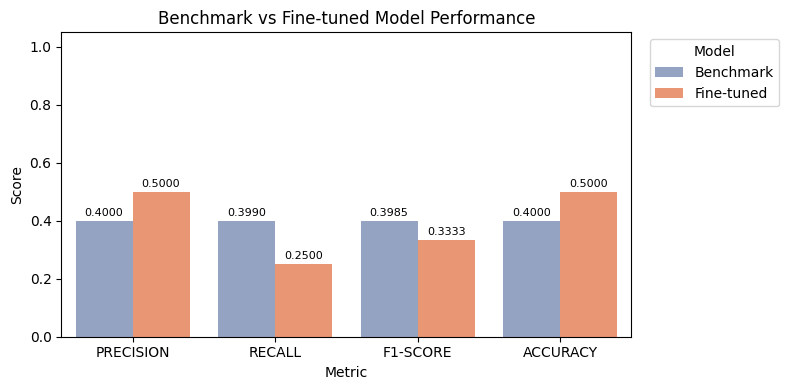

In [42]:
# --- Reports ---
base_report = classification_report(
    baseline_preds, test_df["label_id"],
    target_names=["SUPPORTED", "REFUTED"],
    output_dict=True, zero_division=0, digits=4
)
fine_report = classification_report(
    finetuned_preds, test_df["label_id"],
    target_names=["SUPPORTED", "REFUTED"],
    output_dict=True, zero_division=0, digits=4
)

# --- Convert reports to DataFrames ---
def prepare_df(report, model_name):
    rows = []
    for label in ["SUPPORTED", "REFUTED"]:
        for metric in ["precision", "recall", "f1-score"]:
            rows.append({
                "Metric": metric.upper(),
                "Label": label,
                "Score": report[label][metric],
                "Model": model_name
            })

    # Add accuracy as separate metric
    rows.append({
        "Metric": "ACCURACY",
        "Label": "ALL",
        "Score": report["accuracy"],
        "Model": model_name
    })

    return pd.DataFrame(rows)

df_base = prepare_df(base_report, "Benchmark")
df_fine = prepare_df(fine_report, "Fine-tuned")

plot_df = pd.concat([df_base, df_fine])

# --- Plot ---
plt.figure(figsize=(8,4))
ax = sns.barplot(
    data=plot_df, x="Metric", y="Score", hue="Model",
    palette=["#8da0cb", "#fc8d62"], ci=None
)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", label_type="edge", fontsize=8, padding=2)

# --- Styling ---
plt.title("Benchmark vs Fine-tuned Model Performance", fontsize=12)
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0, 1.05)
plt.legend(title="Model", loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()


| Metric        | Observation (Fine-tuned vs Baseline) | Meaning                                                                                               |
| ------------- | ------------------------------------ | ----------------------------------------------------------------------------------------------------- |
| **Precision** |  Higher                            | Model is *more cautious*: when it says “SUPPORTS” or “REFUTES”, it’s usually correct.                 |
| **Accuracy**  |  Higher                            | Overall more predictions match the labels — good general alignment.                                   |
| **Recall**    |  Lower                             | Model *misses* more true positives — it fails to identify some correct “SUPPORTS” or “REFUTES” cases. |
| **F1-score**  |  Lower                             | Because F1 is the harmonic mean of precision & recall, the drop in recall dominates.                  |

  


The fine-tuned model has become conservative — it learned to avoid making risky or uncertain predictions. Good credibility and reliability (avoids false positives).